In [1]:
import pandas as pd
import pickle
from pmsi.imputers import (
    locf_imputation_1D, 
    knn_imputation_2D,
    multi_point_linear_imputation_1D
)
from pmsi.pmsi_core import PMSIImputer
from pmsi.visualization import (
    plot_periodicity_percentiles,
    plot_pmsi_kernel,
    plot_data_intuition
)
from pmsi.evaluation import evaluate_method, combine_results
from pathlib import Path
from pmsi.evaluation import combine_results, stratify_results_by_periodicity


import numpy as np
from sklearn.impute import KNNImputer

/home/idan/.conda/envs/pypots_env/lib/python3.10/site-packages/hyperopt/atpe.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
N_BOOTSTRAP = 10000
N_PER_KEY = 100

In [3]:
with open('export.pkl', 'rb') as f:
    export = pickle.load(f)

In [4]:
pivot_d, binary_d, good_k, binary_masks = export["pivot_d"], export["binary_d"], export["good_k"], export["binary_masks"]

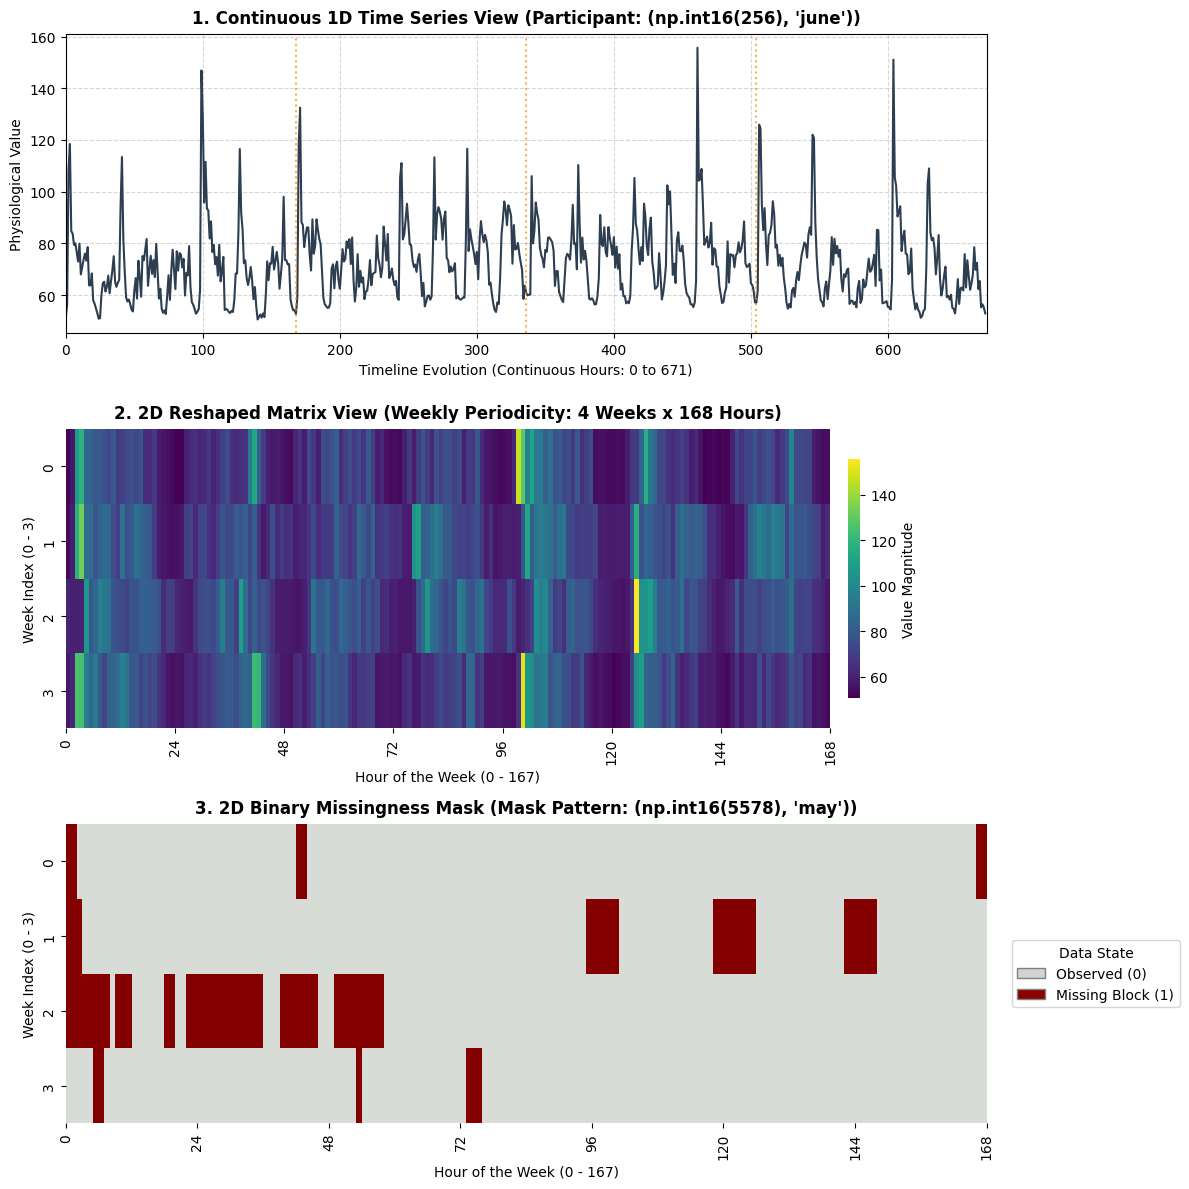

In [5]:
plot_data_intuition(pivot_d, binary_d, good_k, binary_masks)

In [6]:
# 1. Evaluate PMSI (2D)
print("Training PMSI Core...")
pmsi_model = PMSIImputer(n_evals=300)
pmsi_model.fit(pivot_d, binary_d, good_k, binary_masks, n_pairs_per_key=1)

Training PMSI Core...
Fitting PMSI: Running 300 evals via Hyperopt TPE...
100%|██████████| 300/300 [00:26<00:00, 11.54trial/s, best loss: 176.6153049086796] 
Fit Complete. Optimal Params: {'x': np.float64(0.9773422484809919), 'y': np.float64(2.1504731430225346)} | AIC: 176.62


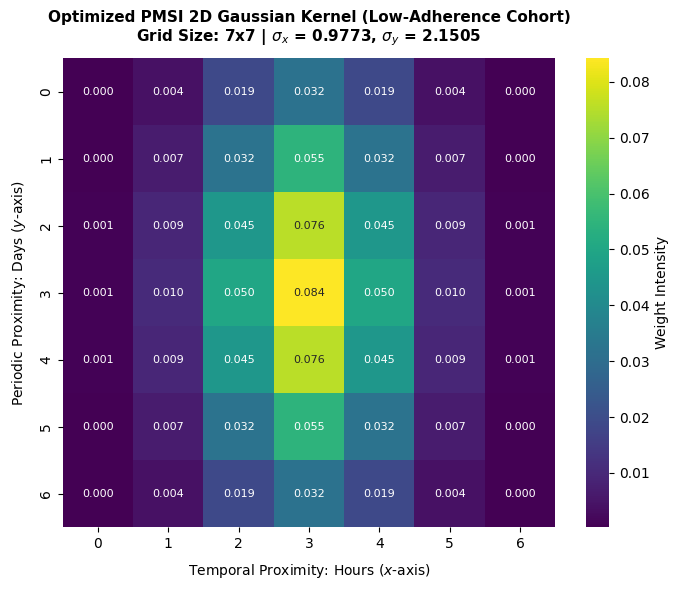

In [7]:
plot_pmsi_kernel(pmsi_model, title_suffix="(Low-Adherence Cohort)")

In [8]:
print("2. Running Benchmarks...")
results = []

2. Running Benchmarks...


In [9]:
print("Evaluating PMSI...")
pmsi_res = evaluate_method(
    name="PMSI", 
    impute_fn=pmsi_model.impute, # Pass the bound method of the fitted class
    seed=42, 
    pivot_d=pivot_d, binary_d=binary_d, good_k=good_k, binary_masks=binary_masks,
    is_2d=True, shape_2d=(28, 24),n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY  
)
results.append(pmsi_res)

Evaluating PMSI...

  METHOD: PMSI    (seed = 42)
  Built 5000 (data, mask) pairs.


  Evaluating PMSI:   0%|                               | 0/5000 [00:00<?, ?it/s]

  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:    21.305 s   (4.26 ms/pair)
  Peak Python memory:     3.484 MB  (tracemalloc)
  RSS delta:              0.719 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE         8.6342    [    8.5323,     8.7351]
  MAE          6.4348    [    6.3682,     6.5016]
  MAPE         8.8407    [    8.7518,     8.9311]
  SMAPE        8.8687    [    8.7830,     8.9561]
  Bias         0.2391    [    0.1472,     0.3337]
  MedAE        5.0000    [    4.9403,     5.0613]


In [10]:
# 2. Evaluate LOCF (1D)
locf_res = evaluate_method(
    name="LOCF", 
    impute_fn=locf_imputation_1D,
    seed=42, 
    pivot_d=pivot_d, 
    binary_d=binary_d, 
    good_k=good_k, 
    binary_masks=binary_masks,
    is_2d=False,
    n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY                    
)
results.append(locf_res)


  METHOD: LOCF    (seed = 42)
  Built 5000 (data, mask) pairs.


  Evaluating LOCF:   0%|                               | 0/5000 [00:00<?, ?it/s]

  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:    18.669 s   (3.73 ms/pair)
  Peak Python memory:     3.446 MB  (tracemalloc)
  RSS delta:              0.324 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE        13.2766    [   13.1179,    13.4347]
  MAE         10.2936    [   10.1750,    10.4138]
  MAPE        14.6580    [   14.4731,    14.8470]
  SMAPE       13.9309    [   13.7776,    14.0842]
  Bias         2.3054    [    2.1305,     2.4822]
  MedAE        8.4389    [    8.3229,     8.5571]


In [11]:
# 3. Evaluate PLI (1D)
res_linear = evaluate_method(
    "PLI", multi_point_linear_imputation_1D, seed=42,
    pivot_d=pivot_d, binary_d=binary_d,
    good_k=good_k, binary_masks=binary_masks,
    is_2d=False, impute_kwargs={"window_size": 7},
    n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY
)
results.append(res_linear)


  METHOD: PLI    (seed = 42)
  Built 5000 (data, mask) pairs.


  Evaluating PLI:   0%|                                | 0/5000 [00:00<?, ?it/s]

  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:    28.416 s   (5.68 ms/pair)
  Peak Python memory:     3.476 MB  (tracemalloc)
  RSS delta:              0.188 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE        11.0495    [   10.9145,    11.1850]
  MAE          8.5011    [    8.4032,     8.5995]
  MAPE        12.3192    [   12.1562,    12.4822]
  SMAPE       11.6247    [   11.4921,    11.7606]
  Bias         2.2364    [    2.0970,     2.3747]
  MedAE        6.8127    [    6.7245,     6.9015]


In [12]:
# 3. Evaluate KNN (2D)
knn_res = evaluate_method(
    name="KNN", 
    impute_fn=knn_imputation_2D,   
    seed=42, 
    pivot_d=pivot_d, 
    binary_d=binary_d, 
    good_k=good_k, 
    binary_masks=binary_masks,
    is_2d=True,                   
    shape_2d=(28, 24),
    n_bootstrap=N_BOOTSTRAP,
    n_per_key=N_PER_KEY
)
results.append(knn_res)


  METHOD: KNN    (seed = 42)
  Built 5000 (data, mask) pairs.


  Evaluating KNN:   0%|                                | 0/5000 [00:00<?, ?it/s]

  Pairs evaluated:    5000    (skipped: 0)
  Wall-clock runtime:   252.094 s   (50.42 ms/pair)
  Peak Python memory:     3.644 MB  (tracemalloc)
  RSS delta:              0.051 MB  (psutil)

  Bootstrap 95% CIs  (n_replicates = 10000):
  Metric         Mean    95% CI                      
  -------  ----------    ----------------------------
  RMSE         9.6180    [    9.5232,     9.7141]
  MAE          7.5727    [    7.5067,     7.6395]
  MAPE        10.7108    [   10.6125,    10.8080]
  SMAPE       10.5367    [   10.4433,    10.6276]
  Bias         0.4597    [    0.3422,     0.5737]
  MedAE        6.5632    [    6.4990,     6.6290]


In [13]:
print("3. Aggregating Results...")
summary_dataframes = combine_results(results, output_dir="./benchmark_outputs")

3. Aggregating Results...

  COMBINED SUMMARY  (all methods, all metrics)
Method  seed  RMSE_mean            RMSE_CI  MAE_mean             MAE_CI  MAPE_mean            MAPE_CI  SMAPE_mean           SMAPE_CI  Bias_mean          Bias_CI  MedAE_mean         MedAE_CI
  PMSI    42     8.6342   [8.5323, 8.7351]    6.4348   [6.3682, 6.5016]     8.8407   [8.7518, 8.9311]      8.8687   [8.7830, 8.9561]     0.2391 [0.1472, 0.3337]      5.0000 [4.9403, 5.0613]
  LOCF    42    13.2766 [13.1179, 13.4347]   10.2936 [10.1750, 10.4138]    14.6580 [14.4731, 14.8470]     13.9309 [13.7776, 14.0842]     2.3054 [2.1305, 2.4822]      8.4389 [8.3229, 8.5571]
   PLI    42    11.0495 [10.9145, 11.1850]    8.5011   [8.4032, 8.5995]    12.3192 [12.1562, 12.4822]     11.6247 [11.4921, 11.7606]     2.2364 [2.0970, 2.3747]      6.8127 [6.7245, 6.9015]
   KNN    42     9.6180   [9.5232, 9.7141]    7.5727   [7.5067, 7.6395]    10.7108 [10.6125, 10.8080]     10.5367 [10.4433, 10.6276]     0.4597 [0.3422, 0.5737]      

4. Stratifying Errors by Weekly Periodicity (ACF)...


/home/idan/.conda/envs/pypots_env/lib/python3.10/site-packages/statsmodels/tsa/stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]


5. Generating Figure 3...


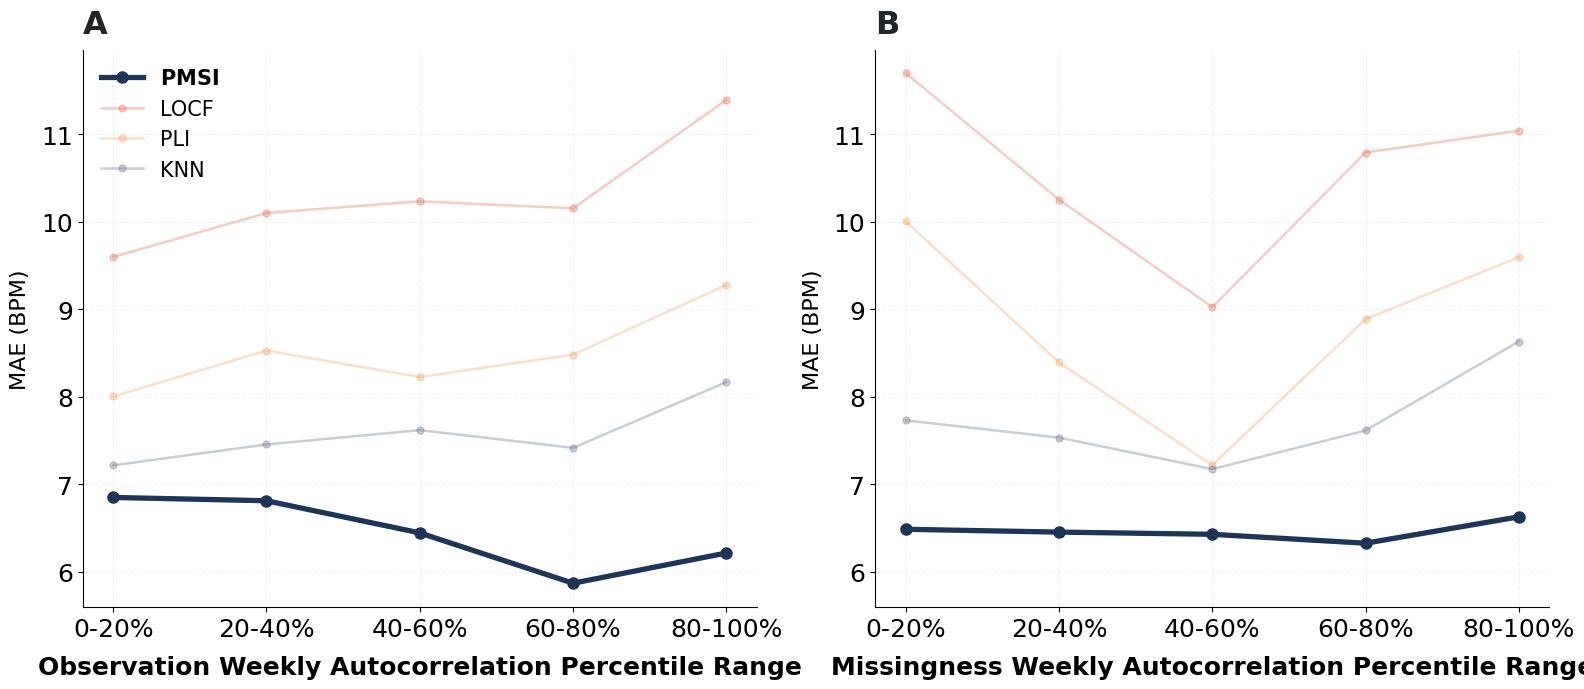

In [14]:
print("4. Stratifying Errors by Weekly Periodicity (ACF)...")
formatted_results = stratify_results_by_periodicity(results, pivot_d, binary_d, good_k)

print("5. Generating Figure 3...")
plot_periodicity_percentiles(formatted_results)